In [1]:
import pandas as pd

# Beyond Blue dataset (already enriched with valence/arousal/emotion)
bb = pd.read_csv("data/beyondblue_data_flattened_transformers_twitter_english_enriched.csv")
bb['date'] = pd.to_datetime(bb['date'], errors='coerce')

# Natural disaster dataset
nd = pd.read_csv("data/natural_disaster_data_cleaned.csv")
nd['start_date'] = pd.to_datetime(nd['start_date'])
nd['end_date'] = pd.to_datetime(nd['end_date'])

In [2]:
bb.head(
)

,parent_post_id,user_id,role,text,date,category,sentiment_dist,valence_s,sentiment_top,sentiment_conf,emotion_dist,valence_e,arousal_e,emotion_top,emotion_conf
0,1,Toby,original,"Struggling at the moment. Hello everyone, this...",2025-07-16,Anxiety,"{'NEGATIVE': 0.6358407139778137, 'NEUTRAL': 0....",-0.573183,NEGATIVE,0.635841,"{'anger': 0.0030326072592288256, 'disgust': 0....",0.079505,0.828274,fear,0.969302
1,1,Morph,commenter,"Hi Toby, welcome and congratulations on your f...",2025-07-17,Anxiety,"{'NEGATIVE': 0.002651855116710067, 'NEUTRAL': ...",0.971309,POSITIVE,0.973961,"{'anger': 0.0023175962269306183, 'disgust': 0....",0.877638,0.714559,joy,0.780846
2,1,AudaciousPoodle,commenter,"Hi Toby, Reading your post sounds just like wh...",2025-07-17,Anxiety,"{'NEGATIVE': 0.7963150143623352, 'NEUTRAL': 0....",-0.754034,NEGATIVE,0.796315,"{'anger': 0.010348315350711346, 'disgust': 0.0...",0.071904,0.324703,sadness,0.913931
3,1,_Gigi_,commenter,"Hello Toby,I'm glad you've decided to reach ou...",2025-07-18,Anxiety,"{'NEGATIVE': 0.01175833772867918, 'NEUTRAL': 0...",0.903619,POSITIVE,0.915377,"{'anger': 0.0013056608149781823, 'disgust': 0....",0.867446,0.751704,joy,0.845598
4,1,Toby,op_reply,My anxiety is affecting my whole life. When I ...,2025-07-18,Anxiety,"{'NEGATIVE': 0.6501989364624023, 'NEUTRAL': 0....",-0.580363,NEGATIVE,0.650199,"{'anger': 0.010438608936965466, 'disgust': 0.0...",0.253667,0.546303,sadness,0.477066


In [3]:
import re

def clean_disaster_list(x):
    if pd.isna(x):
        return []
    # remove brackets and split
    items = re.sub(r'[\[\]\']', '', x).split(',')
    items = [i.strip().lower() for i in items]
    return items

nd['disaster_types'] = nd['disaster_types'].apply(clean_disaster_list)

# normalisation mapping
normalize = {
    "earthquack": "earthquake",
    "earthquake": "earthquake",
    "bushfire": "bushfire",
    "storm": "storm",
    "flood": "flood",
    "cyclone": "cyclone",
    "rainfall": "rainfall",
    "tornado": "tornado",
    "landslide": "landslide"
}

def normalize_types(lst):
    return [normalize.get(i, i) for i in lst]

nd['disaster_types'] = nd['disaster_types'].apply(normalize_types)

In [4]:
nd_expanded = nd.explode("disaster_types").reset_index(drop=True)
nd_expanded.head()

,agrn,state,start_date,end_date,duration_days,disaster_types
0,845,NSW,2019-01-11,2019-01-11,1.0,flood
1,845,NSW,2019-01-11,2019-01-11,1.0,storm
2,856,NSW,2019-01-22,2019-01-23,2.0,storm
3,859,VIC,2019-01-30,2019-01-30,1.0,storm
4,859,VIC,2019-01-30,2019-01-30,1.0,bushfire


In [5]:
from datetime import timedelta

def align_disaster(row, bb_date):
    start = row['start_date']
    end = row['end_date']
    
    pre_start = start - timedelta(days=30)
    post_end = end + timedelta(days=30)

    if pre_start <= bb_date < start:
        return "pre"
    elif start <= bb_date <= end:
        return "during"
    elif end < bb_date <= post_end:
        return "post"
    else:
        return None

In [6]:
aligned_rows = []

for _, post in bb.iterrows():
    post_date = post['date']
    if pd.isna(post_date):
        continue

    matches = nd_expanded[
        (nd_expanded['start_date'] - pd.Timedelta(days=30) <= post_date) &
        (post_date <= nd_expanded['end_date'] + pd.Timedelta(days=30))
    ]

    if len(matches) == 0:
        continue

    for _, d in matches.iterrows():
        aligned_rows.append({
            "bb_id": post['parent_post_id'],
            "user_id": post['user_id'],
            "bb_date": post['date'],
            "disaster_type": d['disaster_types'],
            "disaster_state": d['state'],
            "phase": align_disaster(d, post_date),
            "valence": post['valence_e'],
            "arousal": post['arousal_e'],
            "emotion_top": post['emotion_top']
        })

aligned = pd.DataFrame(aligned_rows)
aligned.head()

,bb_id,user_id,bb_date,disaster_type,disaster_state,phase,valence,arousal,emotion_top
0,2,Shell1,2025-05-23,storm,QLD,post,0.100468,0.807718,fear
1,2,Shell1,2025-05-23,flood,QLD,post,0.100468,0.807718,fear
2,2,Shell1,2025-05-23,storm,NSW,post,0.100468,0.807718,fear
3,2,Shell1,2025-05-23,storm,NSW,post,0.100468,0.807718,fear
4,2,Shell1,2025-05-23,flood,NSW,post,0.100468,0.807718,fear


In [18]:
# show aligned data shape
print("Aligned data shape:", aligned.shape)

Aligned data shape: (524585, 13)


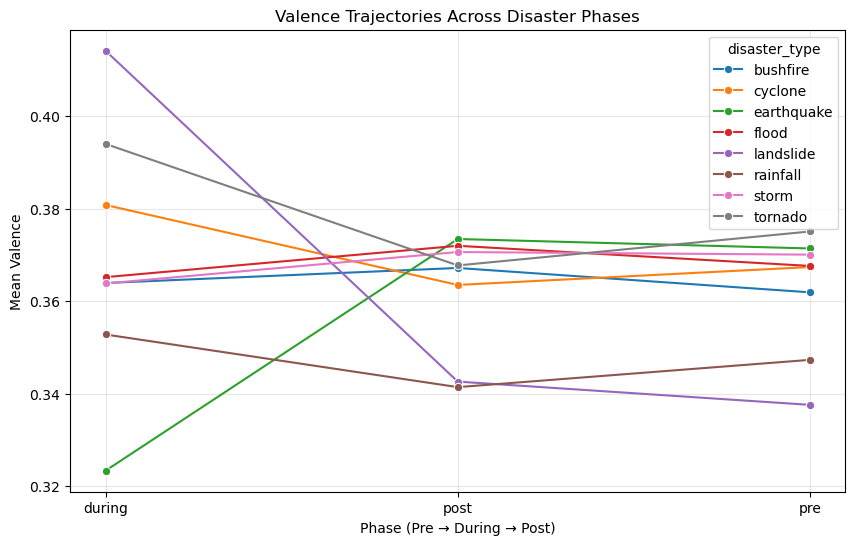

In [7]:
val_curve = aligned.groupby(['disaster_type','phase'])['valence'].mean().reset_index()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.lineplot(data=val_curve, x='phase', y='valence', hue='disaster_type', marker='o')
plt.title("Valence Trajectories Across Disaster Phases")
plt.xlabel("Phase (Pre → During → Post)")
plt.ylabel("Mean Valence")
plt.grid(True, alpha=0.3)
plt.show()

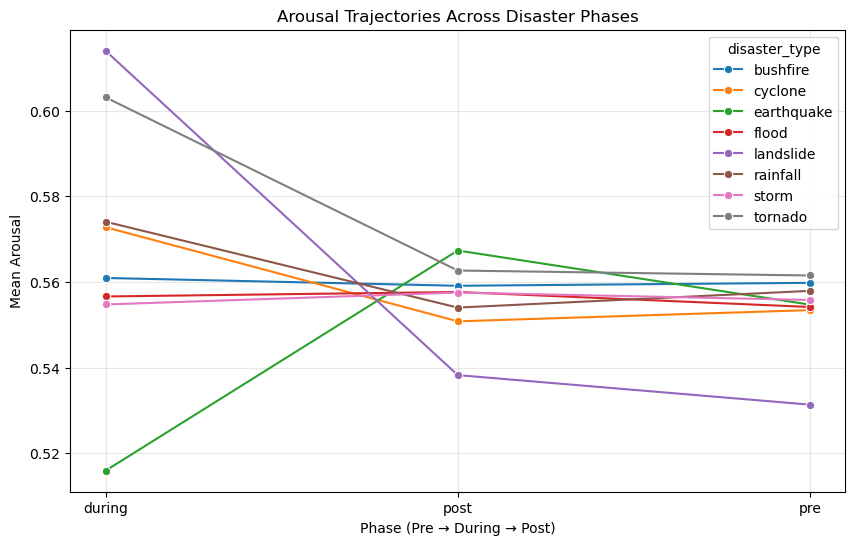

In [8]:
aro_curve = aligned.groupby(['disaster_type','phase'])['arousal'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=aro_curve, x='phase', y='arousal', hue='disaster_type', marker='o')
plt.title("Arousal Trajectories Across Disaster Phases")
plt.xlabel("Phase (Pre → During → Post)")
plt.ylabel("Mean Arousal")
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
shift = aligned.groupby(['disaster_type','phase'])[['valence','arousal']].mean().unstack()
shift

valence                       arousal                    
phase            during      post       pre    during      post       pre
disaster_type                                                            
bushfire       0.363943  0.367193  0.361916  0.560935  0.559110  0.559796
cyclone        0.380830  0.363517  0.367393  0.572798  0.550805  0.553429
earthquake     0.323311  0.373459  0.371416  0.515911  0.567347  0.554703
flood          0.365206  0.371992  0.367629  0.556609  0.557657  0.554157
landslide      0.414210  0.342600  0.337564  0.614012  0.538243  0.531342
rainfall       0.352796  0.341402  0.347306  0.574078  0.554015  0.557922
storm          0.363840  0.370640  0.370073  0.554745  0.557526  0.555795
tornado        0.394046  0.367740  0.375090  0.603136  0.562672  0.561510

In [10]:
import numpy as np

disaster_shifts = []

for d, g in aligned.groupby('disaster_type'):
    pre = g[g['phase']=='pre']['valence'].mean()
    dur = g[g['phase']=='during']['valence'].mean()
    post = g[g['phase']=='post']['valence'].mean()

    disaster_shifts.append({
        'disaster_type': d,
        'pre_to_during': dur - pre,
        'during_to_post': post - dur
    })

pd.DataFrame(disaster_shifts)

,disaster_type,pre_to_during,during_to_post
0,bushfire,0.002026,0.003250
1,cyclone,0.013437,-0.017313
2,earthquake,-0.048105,0.050148
3,flood,-0.002423,0.006787
4,landslide,0.076645,-0.071610
5,rainfall,0.005489,-0.011393
6,storm,-0.006232,0.006800
7,tornado,0.018956,-0.026306


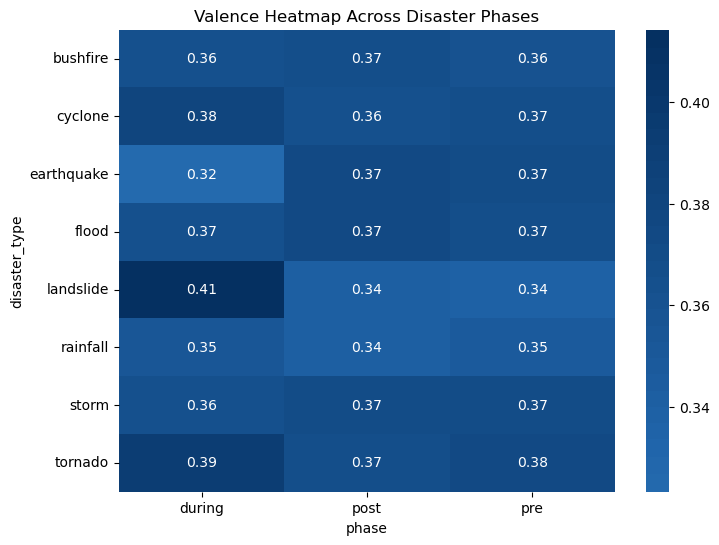

In [11]:
pivot = aligned.pivot_table(
    index='disaster_type',
    columns='phase',
    values='valence',
    aggfunc='mean'
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, cmap="RdBu", center=0)
plt.title("Valence Heatmap Across Disaster Phases")
plt.show()

In [12]:
# Save the aligned dataset
aligned.to_csv("data/beyondblue_x_natural_disaster_data_aligned.csv", index=False)

In [13]:
import pandas as pd

# If duration is in natural disaster dataset, merge it in:
nd = pd.read_csv("data/natural_disaster_data_cleaned.csv")
nd['start_date'] = pd.to_datetime(nd['start_date'])
nd['end_date'] = pd.to_datetime(nd['end_date'])
nd['duration_days'] = (nd['end_date'] - nd['start_date']).dt.days + 1

# Expand for multi-disaster rows
nd['disaster_types'] = nd['disaster_types'].apply(eval)  # if list stored as string
nd_expanded = nd.explode("disaster_types")

aligned['bb_date'] = pd.to_datetime(aligned['bb_date'], errors='coerce')

# Merge duration into aligned dataframe
aligned = aligned.merge(
    nd_expanded[['disaster_types', 'start_date', 'duration_days']],
    left_on=['disaster_type', 'bb_date'],
    right_on=['disaster_types', 'start_date'], 
    how='left'
)

In [14]:
def classify_severity(d):
    if d <= 3:
        return "short"
    elif d <= 10:
        return "medium"
    else:
        return "long"

aligned['severity'] = aligned['duration_days'].apply(classify_severity)

/var/folders/jm/36rrr53s1w388ms7208drrcm0000gn/T/ipykernel_18551/11043187.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=aligned, x='severity', y='valence', palette='Set2')


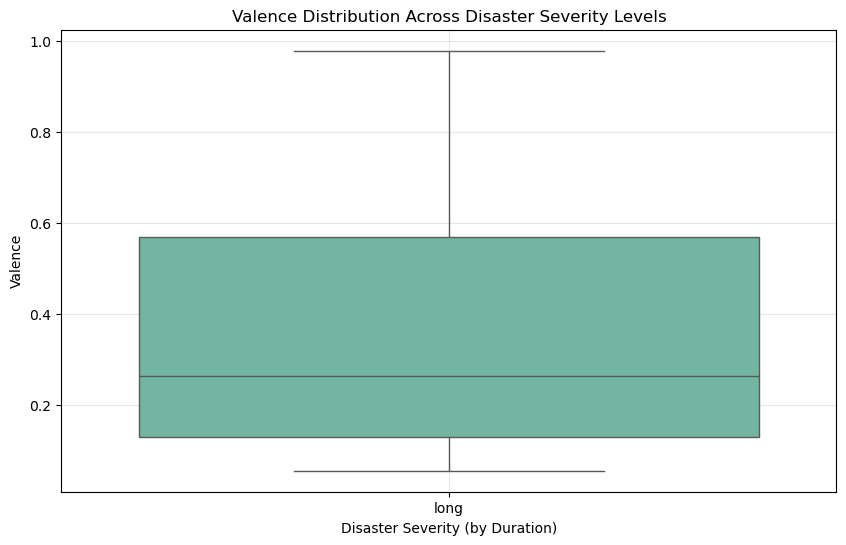

/var/folders/jm/36rrr53s1w388ms7208drrcm0000gn/T/ipykernel_18551/11043187.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=aligned, x='severity', y='arousal', palette='Set1')


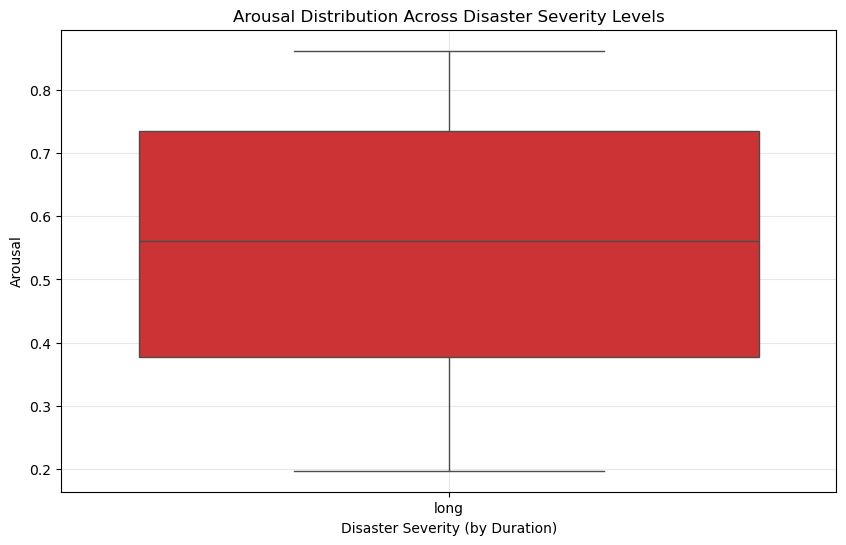

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(data=aligned, x='severity', y='valence', palette='Set2')
plt.title("Valence Distribution Across Disaster Severity Levels")
plt.xlabel("Disaster Severity (by Duration)")
plt.ylabel("Valence")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=aligned, x='severity', y='arousal', palette='Set1')
plt.title("Arousal Distribution Across Disaster Severity Levels")
plt.xlabel("Disaster Severity (by Duration)")
plt.ylabel("Arousal")
plt.grid(True, alpha=0.3)
plt.show()

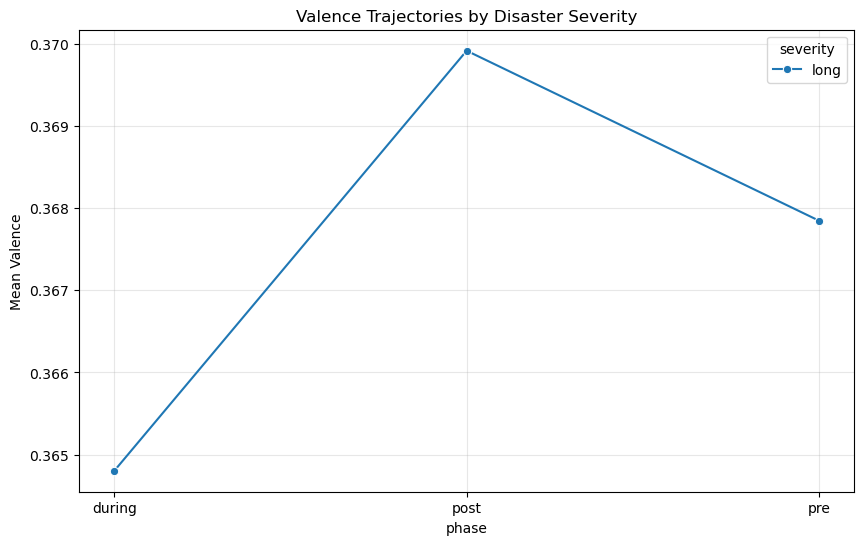

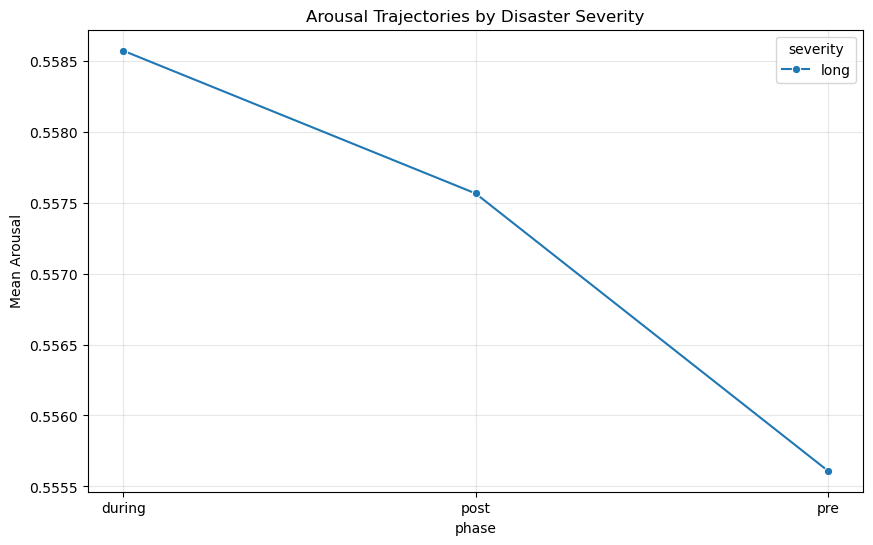

In [16]:
phase_curve = aligned.groupby(['severity','phase'])[['valence','arousal']].mean().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(
    data=phase_curve,
    x='phase',
    y='valence',
    hue='severity',
    marker='o'
)
plt.title("Valence Trajectories by Disaster Severity")
plt.ylabel("Mean Valence")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10,6))
sns.lineplot(
    data=phase_curve,
    x='phase',
    y='arousal',
    hue='severity',
    marker='o'
)
plt.title("Arousal Trajectories by Disaster Severity")
plt.ylabel("Mean Arousal")
plt.grid(True, alpha=0.3)
plt.show()